# Ejemplos de codigo - Adult

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 random values for X
x = np.random.rand(100)

# Create Y as a negative function of X with some random noise
y = -2 * x + np.random.normal(0, 0.2, 100)

data = pd.DataFrame({'X': x, 'Y': y})

In [6]:
# 12) Matriz de correlacion
cor_mat = data[["X", "Y"]].corr(numeric_only=True)
cor_mat


,X,Y
X,1.000000,-0.960409
Y,-0.960409,1.000000


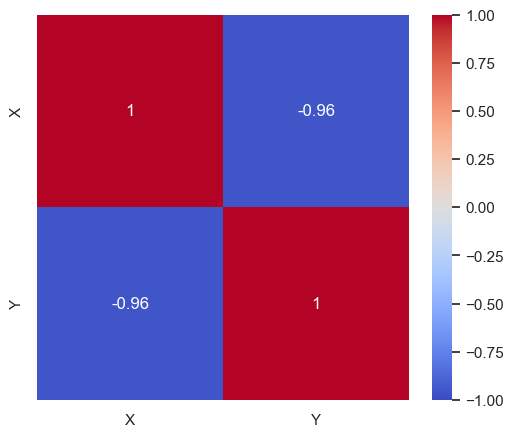

In [9]:
# 12) Heatmap correlacion
plt.figure(figsize=(6, 5))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()


<Axes: xlabel='X', ylabel='Y'>

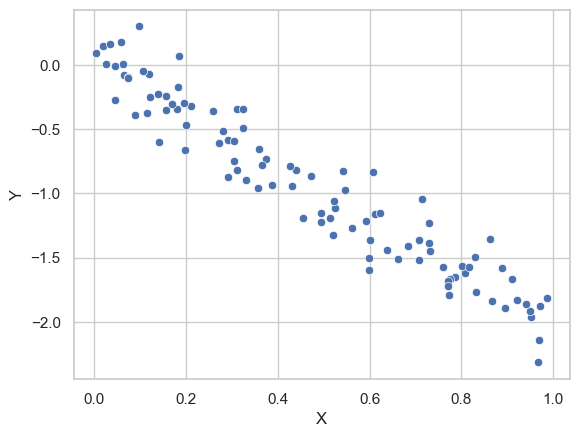

In [11]:
sns.scatterplot(y="Y", x="X", data=data)

In [13]:
reglin = sm.formula.ols("Y ~ X", data=data)

In [14]:
results = reglin.fit()

In [15]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     1165.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.38e-56
Time:                        00:15:33   Log-Likelihood:                 29.797
No. Observations:                 100   AIC:                            -55.59
Df Residuals:                      98   BIC:                            -50.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0430      0.034      1.263      0.210      -0.025       0.111
X             -2.0920      0.061    -34.127      0.000      -2.214      -1.970
==============================================================================
Omnibus:                        0.900   Durbin-Watson:                   2.285
Prob(Omnibus):                  0.638   Jarque-Bera (JB):                0.808
Skew:                           0.217   Prob(JB):                        0.668
Kurtosis:                       2.929   Cond. No.                         4.18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Y = 0.0430 - 2.0920*X

In [34]:
# Estimar valores predichos
data["pred_reglin"] = 0.0430 - 2.0920 * data["X"]
data["pred_reglin_mala"] = 0.0430 + 2.0920 * data["X"]
data["pred_media"] = data["Y"].mean()

In [35]:
data["pred_reglin_resid"] = (data["Y"] - data["pred_reglin"]) ** 2
data["pred_reglin_resid_mala"] = (data["Y"] - data["pred_reglin_mala"]) ** 2
data["pred_media_resid"] = (data["Y"] - data["pred_media"]) ** 2

In [37]:
ss_reglin = data["pred_reglin_resid"].sum()
ss_reglin_mala = data["pred_reglin_resid_mala"].sum()
ss_media = data["pred_media_resid"].sum()

In [38]:
1 - (ss_reglin / ss_media)

np.float64(0.9223860307857203)

In [39]:
# mala
1 - (ss_reglin_mala / ss_media)

np.float64(-12.07671101880175)